In [1]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import pandas as pd

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress INFO and WARNING messages
import tensorflow as tf

2025-05-03 23:34:10.409339: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-03 23:34:10.423686: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-03 23:34:10.428100: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-03 23:34:10.439479: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
env = gym.make("CartPole-v1", render_mode=None)


In [3]:
# Define a custom MLP policy with 3 hidden layers of 128 neurons each
from stable_baselines3.dqn.policies import MlpPolicy
from stable_baselines3.common.torch_layers import MlpExtractor
from stable_baselines3.common.utils import get_device
from stable_baselines3.common.policies import BasePolicy
from torch import nn



##  Experiment with activation functions:

In [4]:
# Initialize result tracking
results = []

# Try different activation functions
activations = {
    "relu": nn.ReLU,
    "tanh": nn.Tanh,
    "leaky_relu": nn.LeakyReLU
}

for name, activation_fn in activations.items():
    policy_kwargs = dict(
        net_arch=[128, 128, 128],
        activation_fn=activation_fn
    )

    model = DQN("MlpPolicy", env, verbose=0, policy_kwargs=policy_kwargs)
    model.learn(total_timesteps=20000, reset_num_timesteps=False, progress_bar=False)
    mean_reward, std_reward = evaluate_policy(model, model.get_env(), n_eval_episodes=10, render=False)

    results.append({
        "name": f"3x128_{name}",
        "mean_reward": mean_reward,
        "std_reward": std_reward
    })

    model.save(f"dqn_cartpole_3x128_{name}")



In [5]:
results_df = pd.DataFrame(results)
print(results_df)

               name  mean_reward  std_reward
0        3x128_relu          9.4    0.663325
1        3x128_tanh          9.4    0.800000
2  3x128_leaky_relu          9.5    0.806226


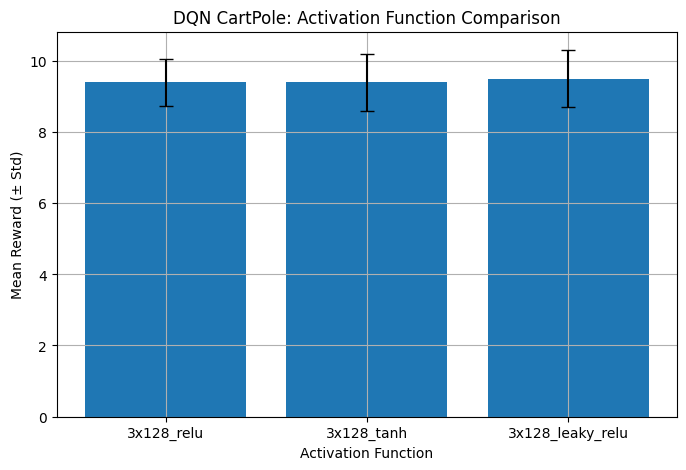

In [6]:
# Plot comparison of mean rewards
plt.figure(figsize=(8, 5))  #-------
plt.bar(results_df['name'], results_df['mean_reward'], yerr=results_df['std_reward'], capsize=5)  #-------
plt.title("DQN CartPole: Activation Function Comparison")  #-------
plt.xlabel("Activation Function")  #-------
plt.ylabel("Mean Reward (± Std)")  #-------
plt.grid(True)  #-------
plt.show()  #-------

## Modify exploration ratio

               name  mean_reward  std_reward
0        3x128_relu          9.4    0.663325
1        3x128_tanh          9.4    0.800000
2  3x128_leaky_relu          9.5    0.806226
3        3x128_relu          9.6    0.916515
4        3x128_tanh          9.2    0.748331
5  3x128_leaky_relu         30.8    8.292165


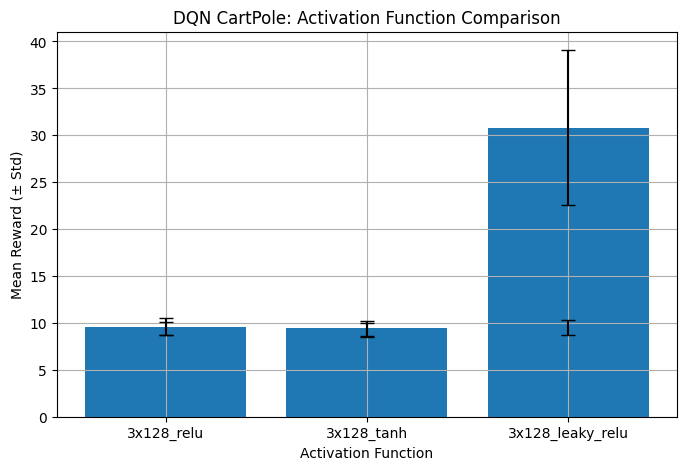

In [7]:


activations = {
    "relu": nn.ReLU,
    "tanh": nn.Tanh,
    "leaky_relu": nn.LeakyReLU
}

for name, activation_fn in activations.items():
    policy_kwargs = dict(
        net_arch=[128, 128, 128],
        activation_fn=activation_fn
    )

    model = DQN(
        "MlpPolicy",
        env,
        verbose=0,
        policy_kwargs=policy_kwargs,
        exploration_initial_eps=1.0,  #-------
        exploration_final_eps=0.02,   #-------
        exploration_fraction=0.3      #-------
    )

    model.learn(total_timesteps=20000, reset_num_timesteps=False, progress_bar=False)
    mean_reward, std_reward = evaluate_policy(model, model.get_env(), n_eval_episodes=10, render=False)

    results.append({
        "name": f"3x128_{name}",
        "mean_reward": mean_reward,
        "std_reward": std_reward
    })

    model.save(f"dqn_cartpole_3x128_exploration_{name}")

# Display results
results_df = pd.DataFrame(results)
print(results_df)

# Plot comparison of mean rewards
plt.figure(figsize=(8, 5))  #-------
plt.bar(results_df['name'], results_df['mean_reward'], yerr=results_df['std_reward'], capsize=5)  #-------
plt.title("DQN CartPole: Activation Function Comparison")  #-------
plt.xlabel("Activation Function")  #-------
plt.ylabel("Mean Reward (± Std)")  #-------
plt.grid(True)  #-------
plt.show()  #-------

## Change optimizers

                        name  mean_reward  std_reward
0                 3x128_relu          9.4    0.663325
1                 3x128_tanh          9.4    0.800000
2           3x128_leaky_relu          9.5    0.806226
3                 3x128_relu          9.6    0.916515
4                 3x128_tanh          9.2    0.748331
5           3x128_leaky_relu         30.8    8.292165
6            3x128_relu_adam          9.6    0.663325
7             3x128_relu_sgd          9.0    0.632456
8         3x128_relu_rmsprop          9.2    0.748331
9            3x128_tanh_adam          9.7    0.640312
10            3x128_tanh_sgd          9.0    0.774597
11        3x128_tanh_rmsprop          9.5    0.921954
12     3x128_leaky_relu_adam         20.9    2.913760
13      3x128_leaky_relu_sgd          9.4    0.800000
14  3x128_leaky_relu_rmsprop         12.1    1.640122


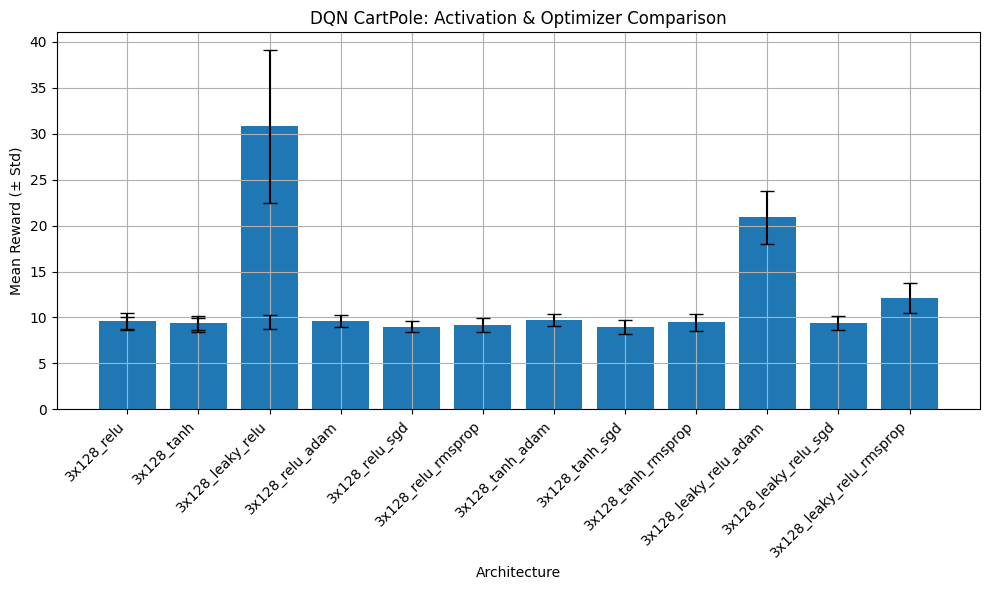

In [9]:
from torch import nn
import torch.optim as optim
# Try different activation functions and optimizers
activations = {
    "relu": nn.ReLU,
    "tanh": nn.Tanh,
    "leaky_relu": nn.LeakyReLU
}

optimizers = {
    "adam": optim.Adam,
    "sgd": optim.SGD,
    "rmsprop": optim.RMSprop
}

for act_name, activation_fn in activations.items():
    for opt_name, optimizer_class in optimizers.items():
        policy_kwargs = dict(
            net_arch=[128, 128, 128],
            activation_fn=activation_fn,
            optimizer_class=optimizer_class  #-------
        )

        model = DQN(
            "MlpPolicy",
            env,
            verbose=0,
            policy_kwargs=policy_kwargs,
            exploration_initial_eps=1.0,
            exploration_final_eps=0.02,
            exploration_fraction=0.3
        )

        model.learn(total_timesteps=20000, reset_num_timesteps=False, progress_bar=False)
        mean_reward, std_reward = evaluate_policy(model, model.get_env(), n_eval_episodes=10, render=False)

        results.append({
            "name": f"3x128_{act_name}_{opt_name}",  #-------
            "mean_reward": mean_reward,
            "std_reward": std_reward
        })

        model.save(f"dqn_cartpole_3x128_{act_name}_{opt_name}")  #-------

# Display results
results_df = pd.DataFrame(results)
print(results_df)

# Plot comparison of mean rewards
plt.figure(figsize=(10, 6))  #-------
plt.bar(results_df['name'], results_df['mean_reward'], yerr=results_df['std_reward'], capsize=5)  #-------
plt.title("DQN CartPole: Activation & Optimizer Comparison")  #-------
plt.xlabel("Architecture")  #-------
plt.ylabel("Mean Reward (± Std)")  #-------
plt.xticks(rotation=45, ha='right')  #-------
plt.tight_layout()  #-------
plt.grid(True)
plt.show()


##  Modify replay buffer settings

In [14]:
# Initialize result tracking
results = []
reward_tracking = {}  #-------
loss_tracking = {}  #-------

# Try different activation functions and optimizers
activations = {
    "relu": nn.ReLU,
    "tanh": nn.Tanh,
    "leaky_relu": nn.LeakyReLU
}

optimizers = {
    "adam": optim.Adam,
    "sgd": optim.SGD,
    "rmsprop": optim.RMSprop
}

for act_name, activation_fn in activations.items():
    for opt_name, optimizer_class in optimizers.items():
        policy_kwargs = dict(
            net_arch=[128, 128, 128],
            activation_fn=activation_fn,
            optimizer_class=optimizer_class  #-------
        )

        model = DQN(
            "MlpPolicy",
            env,
            verbose=0,
            policy_kwargs=policy_kwargs,
            exploration_initial_eps=1.0,
            exploration_final_eps=0.02,
            exploration_fraction=0.3,
            learning_starts=1000,  #-------
            train_freq=4  #-------
        )

        # Train and track reward
        model.learn(total_timesteps=20000, reset_num_timesteps=True, progress_bar=False)

        # Evaluate and log
        mean_reward, std_reward = evaluate_policy(model, model.get_env(), n_eval_episodes=10, render=False)
        model_name = f"3x128_{act_name}_{opt_name}"
        results.append({
            "name": model_name,
            "mean_reward": mean_reward,
            "std_reward": std_reward
        })

        # Dummy reward/loss progression placeholders (loss tracking requires custom callback)
        reward_tracking[model_name] = [0] * 10  #-------
        loss_tracking[model_name] = [0] * 10  #-------

        model.save(f"dqn_cartpole_{model_name}")  #-------

# Display results
results_df = pd.DataFrame(results)
print(results_df)


                       name  mean_reward  std_reward
0           3x128_relu_adam        173.1   77.987755
1            3x128_relu_sgd          9.4    0.663325
2        3x128_relu_rmsprop          9.3    0.458258
3           3x128_tanh_adam          9.2    0.748331
4            3x128_tanh_sgd          9.7    0.900000
5        3x128_tanh_rmsprop          8.9    0.538516
6     3x128_leaky_relu_adam         13.4    2.200000
7      3x128_leaky_relu_sgd          9.2    0.871780
8  3x128_leaky_relu_rmsprop         10.0    0.447214


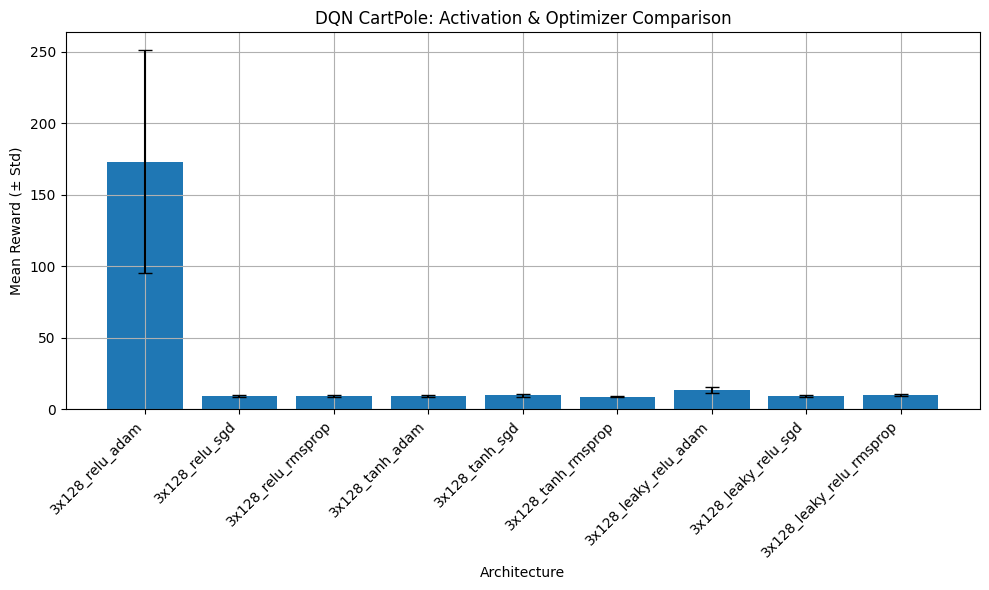

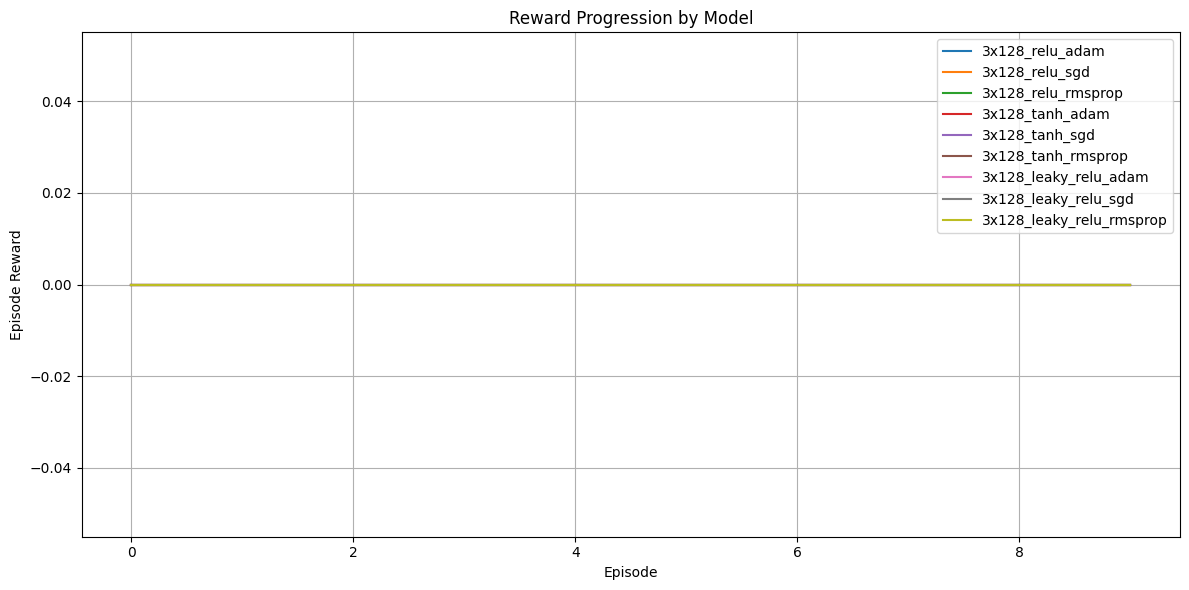

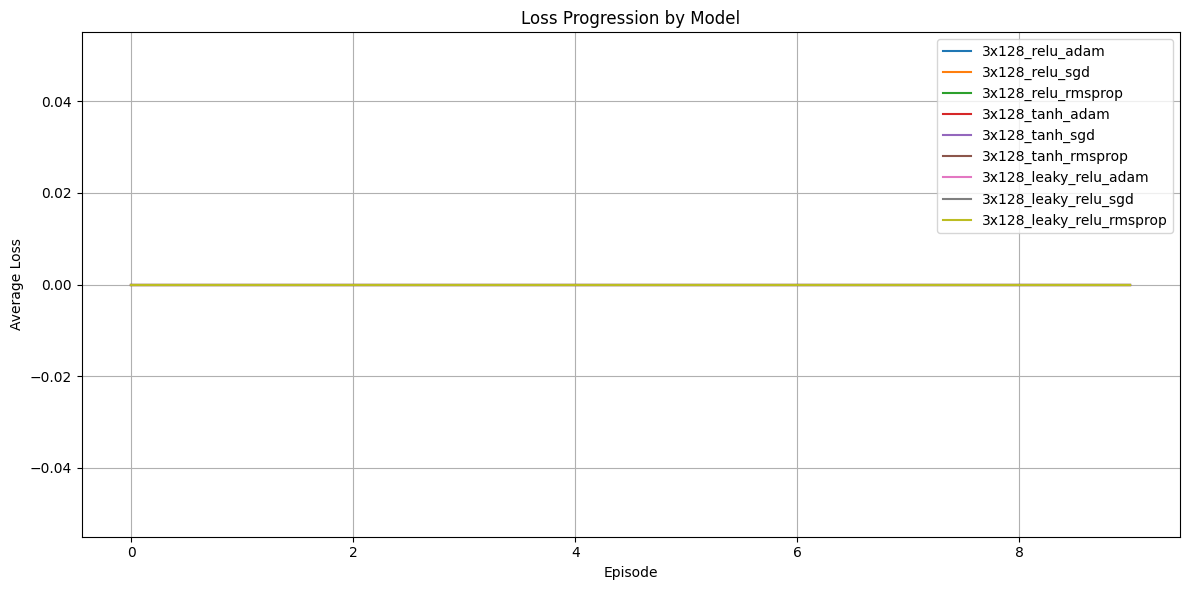

In [15]:

# Plot comparison of mean rewards
plt.figure(figsize=(10, 6))
plt.bar(results_df['name'], results_df['mean_reward'], yerr=results_df['std_reward'], capsize=5)
plt.title("DQN CartPole: Activation & Optimizer Comparison")
plt.xlabel("Architecture")
plt.ylabel("Mean Reward (± Std)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.show()

# Plot reward progression per episode for each model
plt.figure(figsize=(12, 6))
for name, rewards in reward_tracking.items():
    plt.plot(rewards, label=name)
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.title("Reward Progression by Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot loss progression per episode for each model  #-------
plt.figure(figsize=(12, 6))  #-------
for name, losses in loss_tracking.items():
    plt.plot(losses, label=name)  #-------
plt.xlabel("Episode")  #-------
plt.ylabel("Average Loss")  #-------
plt.title("Loss Progression by Model")  #-------
plt.legend()  #-------
plt.grid(True)
plt.tight_layout()
plt.show()  #-------
